In [25]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu
GPU available: False


In [26]:
device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np


In [28]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [15]:
import os
import torchvision

data_root = "./data"
cifar_dir = os.path.join(data_root, "cifar-10-batches-py")

# Check first: download only if the extracted folder is missing
need_download = not os.path.isdir(cifar_dir)

if need_download:
    print("Dataset not found. Downloading...")
else:
    print("Dataset found. Using existing files.")

train_dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,
    download=need_download,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=False,
    download=need_download,
    transform=transform
)

Dataset not found. Downloading...


100%|██████████| 170M/170M [25:24<00:00, 112kB/s]


In [16]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [17]:
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Training images: 50000
Testing images: 10000
Batch image shape: torch.Size([64, 3, 32, 32])
Batch label shape: torch.Size([64])


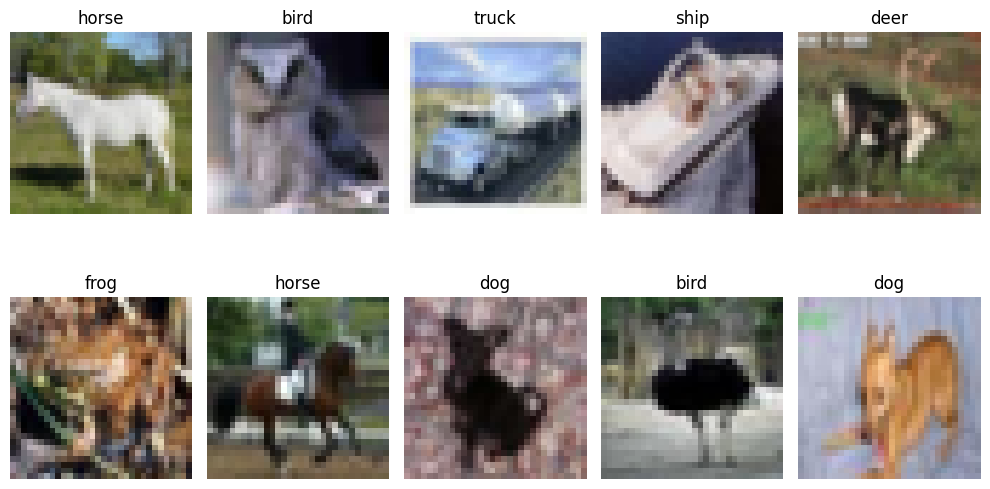

In [18]:
classes = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

images, labels = next(iter(train_loader))

images = images / 2 + 0.5

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.fc1 = nn.Linear(
            64 * 8 * 8,
            64
        )

        self.fc2 = nn.Linear(
            64,
            10
        )

    def forward(self, x):

        x = self.pool(torch.relu(self.conv1(x)))

        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(-1, 64 * 8 * 8)

        x = torch.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [20]:
model = CNN()

model = model.to(device)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [21]:
import torch
device = torch.device("cpu")
model = CNN()
model = model.to(device)

In [22]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 1.3643 Accuracy: 50.72%
Epoch [2/5] Loss: 0.9977 Accuracy: 64.93%
Epoch [3/5] Loss: 0.8583 Accuracy: 69.89%
Epoch [4/5] Loss: 0.7553 Accuracy: 73.58%
Epoch [5/5] Loss: 0.6695 Accuracy: 76.53%


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

### Training Performance Visualization

Let's visualize the training loss and accuracy over the epochs to observe how the model learned.

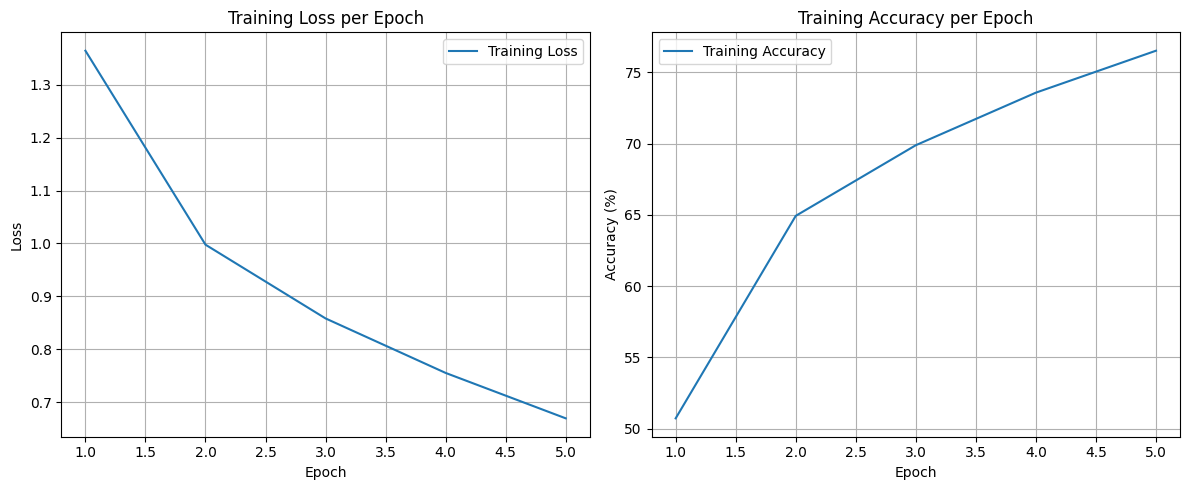

In [24]:
plt.figure(figsize=(12, 5))

# Plotting training loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()
plt.grid(True)

# Plotting training accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy per Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()